# Figure S6A

In [1]:
library(Seurat)
library(ggplot2)

载入需要的程辑包：SeuratObject

载入需要的程辑包：sp


载入程辑包：‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
PBMC <- readRDS("PBMC.Rds")
PBMC
head(PBMC@meta.data)
color <- c("#ea5545", "#27aeef", "#ef9b20", "#b33dc6", "#edbf33", "#87bc45", "#ede15b",  "#0d88e6",
           "#1a53ff", "#bdcf32", "#f46a9b",  "#7c1158", "#b30000","#4421af")

An object of class Seurat 
70716 features across 19455 samples within 2 assays 
Active assay: RNA (35358 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: orig.count
 3 dimensional reductions calculated: pca, tsne, umap

,orig.ident,nCount_RNA,nFeature_RNA,CellBarcodes,Cellnames,nCount_HTO,nFeature_HTO,nCount_pseudoHTO,nFeature_pseudoHTO,HTO_maxID,⋯,RNA_snn_res.1.8,RNA_snn_res.1.9,RNA_snn_res.2,decount_score,old_anno,anno,anno_new,totalCNV,nCount_orig.count,nFeature_orig.count
,<fct>,<dbl>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,⋯,<fct>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
CELL4_N1,lib17-chip3,2000,1054,AACAGACGACCCTCAGGTCG,CELL4_N1,36,2,39,3,Case1,⋯,17,17,18,0.06307971,Mature NK T cell,CD8+ cytotoxic T cell,Case1,704,2042,1062
CELL5_N1,lib17-chip3,1148,729,AACAGACGACCGCACAGGTA,CELL5_N1,12,2,15,3,Case1,⋯,0,3,0,0.09396679,NA,Natural killer cell,Case1,1050,1185,740
CELL7_N1,lib17-chip3,2045,1049,AACAGCATAGCCTGTTGCGC,CELL7_N1,40,2,43,3,Case1,⋯,4,5,2,0.03652518,CD14+ monocyte,CD14+ monocyte,Case1,848,2064,1054
CELL8_N1,lib17-chip3,4861,2196,AACCTAGTAGATATGTCTCA,CELL8_N1,33,2,36,3,Case2,⋯,7,7,8,0.02897729,Pro-B cell,Transitional B cell,Transitional B cell,956,4900,2205
CELL9_N1,lib17-chip3,1170,728,AACCTAGTAGCACAGAAGCC,CELL9_N1,26,3,29,3,Case1,⋯,0,3,0,0.05322462,Natural killer cell,Natural killer cell,Case1,1405,1186,735
CELL10_N1,lib17-chip3,14622,3908,AACCTGGTGAAACATTCCTC,CELL10_N1,40,3,43,3,Case3,⋯,28,28,29,0.07923297,Plasma cell,Plasma cell,Plasma cell,300,15381,3961


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


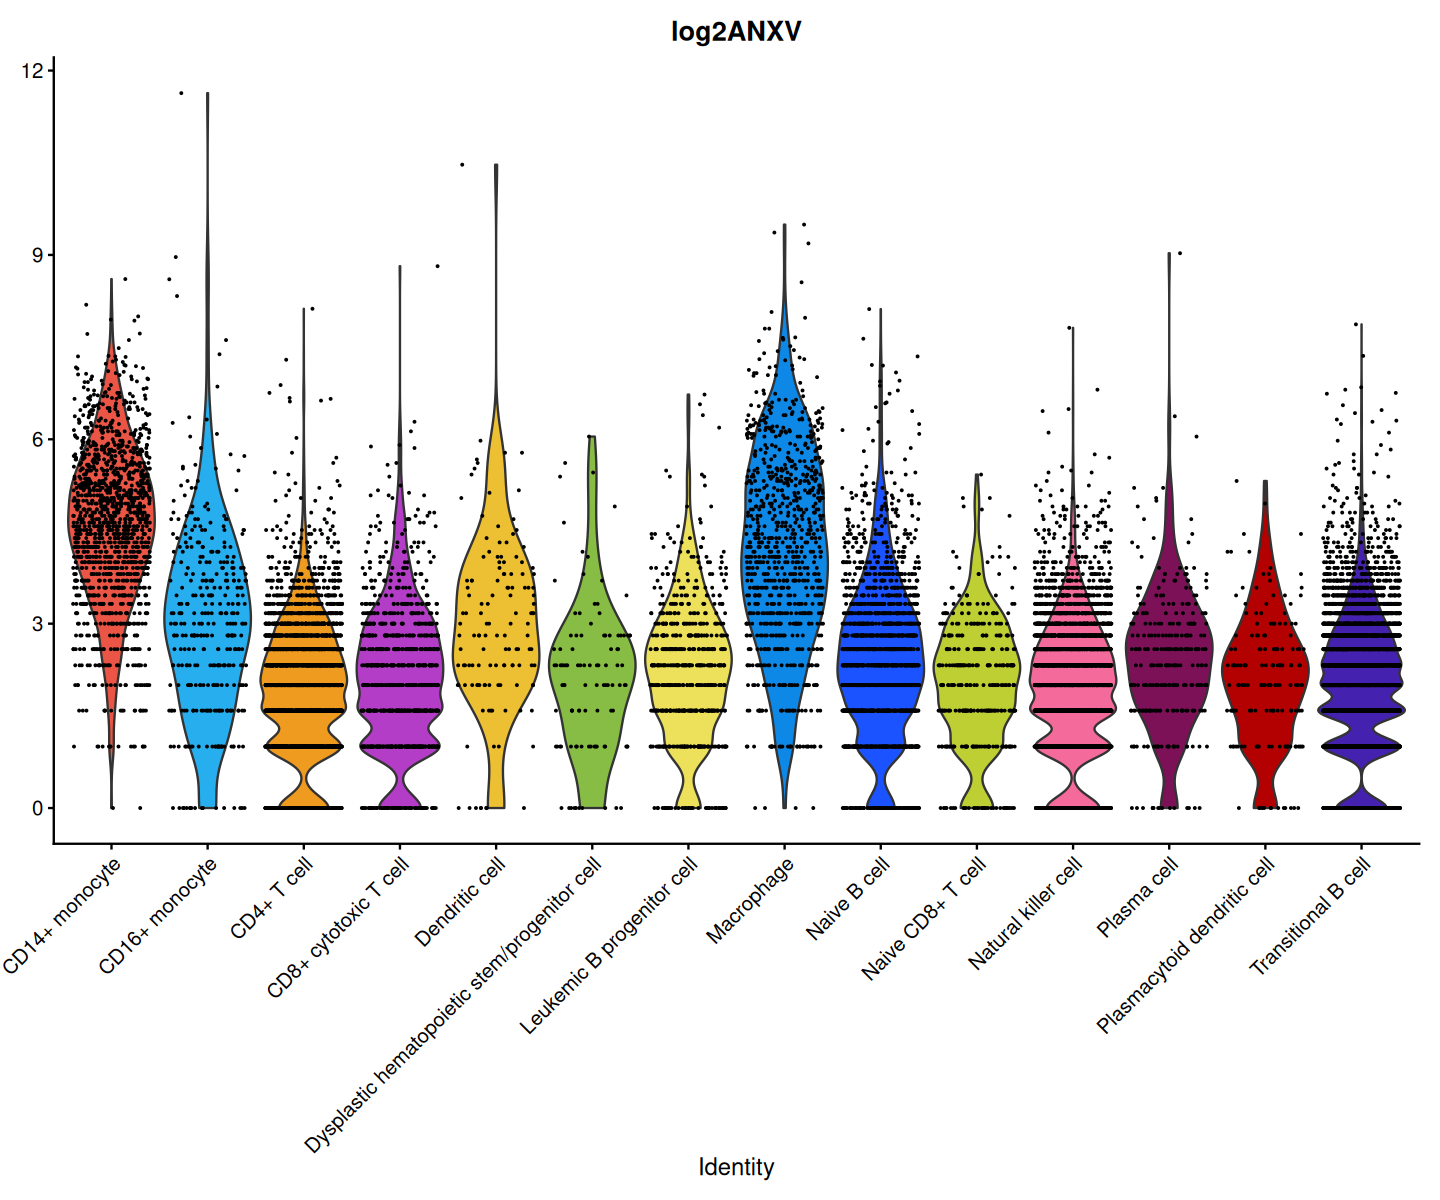

In [3]:
options(repr.plot.width=12, repr.plot.height=10)

VlnPlot(PBMC,features = "log2ANXV",cols = color,group.by = "anno")+RotatedAxis()+theme(legend.position = "none")
ggsave(filename = "log2ANXV_vln.pdf",width = 12,height = 10,units = "in",dpi = 300)

# Figure S6C

In [4]:
library(Seurat)
library(stringr)
library(ggplot2)
library(reshape2)
library(mgcv)

载入需要的程辑包：nlme

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.



In [5]:
PBMC <- readRDS("PBMC.Rds")
PBMC
head(PBMC@meta.data)

An object of class Seurat 
70716 features across 19455 samples within 2 assays 
Active assay: RNA (35358 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: orig.count
 3 dimensional reductions calculated: pca, tsne, umap

,orig.ident,nCount_RNA,nFeature_RNA,CellBarcodes,Cellnames,nCount_HTO,nFeature_HTO,nCount_pseudoHTO,nFeature_pseudoHTO,HTO_maxID,⋯,RNA_snn_res.1.8,RNA_snn_res.1.9,RNA_snn_res.2,decount_score,old_anno,anno,anno_new,totalCNV,nCount_orig.count,nFeature_orig.count
,<fct>,<dbl>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,⋯,<fct>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
CELL4_N1,lib17-chip3,2000,1054,AACAGACGACCCTCAGGTCG,CELL4_N1,36,2,39,3,Case1,⋯,17,17,18,0.06307971,Mature NK T cell,CD8+ cytotoxic T cell,Case1,704,2042,1062
CELL5_N1,lib17-chip3,1148,729,AACAGACGACCGCACAGGTA,CELL5_N1,12,2,15,3,Case1,⋯,0,3,0,0.09396679,NA,Natural killer cell,Case1,1050,1185,740
CELL7_N1,lib17-chip3,2045,1049,AACAGCATAGCCTGTTGCGC,CELL7_N1,40,2,43,3,Case1,⋯,4,5,2,0.03652518,CD14+ monocyte,CD14+ monocyte,Case1,848,2064,1054
CELL8_N1,lib17-chip3,4861,2196,AACCTAGTAGATATGTCTCA,CELL8_N1,33,2,36,3,Case2,⋯,7,7,8,0.02897729,Pro-B cell,Transitional B cell,Transitional B cell,956,4900,2205
CELL9_N1,lib17-chip3,1170,728,AACCTAGTAGCACAGAAGCC,CELL9_N1,26,3,29,3,Case1,⋯,0,3,0,0.05322462,Natural killer cell,Natural killer cell,Case1,1405,1186,735
CELL10_N1,lib17-chip3,14622,3908,AACCTGGTGAAACATTCCTC,CELL10_N1,40,3,43,3,Case3,⋯,28,28,29,0.07923297,Plasma cell,Plasma cell,Plasma cell,300,15381,3961


In [6]:
genelist <- read.delim("pathways.tsv")
head(genelist)

,pathway_name,genes
,<chr>,<chr>
1,apoptotic signaling pathway,"TRAF5,HIP1,BCL2L2,URI1,P2RX4,SORT1,TMEM109,IFI6,UACA,NFKBIZ,BAG6,DAPK1,DEDD2,BRSK2,DYRK2,SHH,ACVR1B,EYA2,SPN,DPF2,RPS27L,CD27,TRADD,DDX3X,SCN2A,IER3,CRH,POLB,SHISA5,MSH2,EDA2R,TMBIM6,PPP2R5C,SST,QRICH1,ERN2,CDKN2A,ATP2A1,IFI27,HIPK2,TNFSF10,TNFRSF10C,TNFRSF10B,POU4F2,IL2,DIABLO,ZNF622,JMY,EP300,BNIP3,DAPL1,TRAF2,EI24,CRIP1,ITM2B,CASP8,CASP3,CASP2,APAF1,PIK3R1,TNFRSF12A,PYCARD,AIFM1,PRKCA,TNFRSF1B,CIDEB,IL33,G0S2,PHLDA3,ZNF385B,UBE4B,ABL1,SIRT1,PARP2,LGALS12,STK24,SELENOK,HIP1R,RIPK3,DAXX,MOAP1,GGCT,BLOC1S2,ACVR1C,ADORA1,CARD8,ATP2A3,ERO1A,TNFRSF25,CUL5,GABARAP,CARD9,BCL2A1,BAG3,JAK2,DIDO1,MYBBP1A,TNFRSF1A,CHAC1,C9orf16,PDCD10,RHOT1,RHOT2,PDK2,PDK1,DNAJC10,MAP3K5,BAD,CLEC7A,BBC3,SGPP1,TM2D1,RAF1,AEN,XPA,RIPK1,SYK,PRKCD,CASP7,BCL2,IFI27L1,GSK3B,GSK3A,FGFR3,EPHA2,FHIT,HINT1,FAS,TIMM50,HIC1,TICAM1,STK25,LOC122513141,CIB1,ARL6IP5,MCL1,BCL2L1,BAX,CLU,CD70,TNF,TNFRSF1A,MLLT11,ATAD5,BBC3,CEBPB,TP63,PAWR,IFI27L2,CYP1B1,DEDD,IFI16,COA8,PTGIS,XBP1,DDX5,PPP1R13B,CD28,BCL10,ERN1,MLH1,DDX47,APAF1,UMOD,CD3E,TOPORS,SPI1,BAK1,CDIP1,CASP8AP2,BTK,TMEM117,PERP,SMAD3,PDCD6,PPP1R15A,BOK,RNF41,MAEL,MELK,ITPR1,BCL3,ATF2,IGF1,MAP2K4,KCNQ3,FOXO3,BCL2L11,TNFSF12,CASP2,CASP3,SGPL1,KRT8,KRT18,DAPK3,PRODH,LCN2,RRP8,ATP7A,CASP8,VDAC2,IKBKE,DELE1,NFATC4,NLRP1,METTL21C,E2F1,PDE3A,SSTR3,CASP4,DAB2IP,IL12A,CD24,PML,IL6R,INHBA,NBN,NOL3,CD38,GSKIP,NDUFA13,CASP6,CASP9,CASP7,BEX3,ATF4,PTH,SFN,BNIP3L,CDKN1A,NGFR,ANXA6,NGF,TGFB1,HRAS,MYC,ERCC2,FZD9,ERBB3,TNF,POU4F1,IL1B,IL1A,IFNG,FNIP2,HTRA2,CYCS,SLFN12,P2RX7,CD5,BRCA2,BCL2L10,TP53,TNFRSF10A,CHEK2,DDIT4,STK11,HSPE1,DAP3,DAP,BRCA1,NF1,RTL10,HIPK1,TGFB2,FASLG,MSH6,TMEM238L,TFPT,FASTK,E2F2,DDIT3,BID,NUPR1,SNW1,LAPTM5,TLR3,ZDHHC3,CRADD,ITGAV,MKNK2,PRKDC,ST20,PMAIP1,PIDD1,ERCC6,TP53BP2,CUL4A,CUL3,CUL2,CUL1,PDPK1,FGF10,CFLAR,BIRC2,BIRC3,SMAD4,SOD2,TP73,SIVA1,PPARD,RNF186,TRIB3,USP28,NODAL,FADD,CAV1,WWOX,ATM,GPX1"
2,autophagic cell death,"BNIP3,SH3GLB1,TP53INP1,CDKN2D,CDKN1B"
3,execution phase of apoptosis,"BLVRA,DFFA,GPER1,NFKBIZ,MADD,DEDD2,DNASE2,ERN2,BNIP1,CIDEC,CIDEB,STK24,ACVR1C,EXOG,BBC3,COLEC11,DNASE2B,COL6A1,BAX,BBC3,CDK5RAP3,AIFM3,DICER1,PLSCR2,XKR8,XKR4,XKR7,XKR9,CTSD,ACIN1,TRPC5,SHARPIN,BOK,NME1,CASP2,CASP3,CASP8,NPR2,CASP7,XKR6,TAOK1,TOP2A,DFFB,CECR2,VPS54,HTRA2,CYCS,AKT1,CAPN10,BLCAP,ENDOG,PLSCR1,FOXL2,DNASE1L3"
4,inflammatory cell apoptotic process,"PLEKHO2,CTSL,HCAR2,IL6,ZMPSTE24,IRF3,FASLG"
5,intrinsic apoptotic signaling pathway by p53 class mediator,"URI1,TMEM109,BAG6,DYRK2,RPS27L,SHISA5,MSH2,EDA2R,PPP2R5C,HIPK2,POU4F2,JMY,EP300,PYCARD,PHLDA3,ZNF385B,SIRT1,MYBBP1A,PDK2,BBC3,AEN,FHIT,HINT1,BAX,ATAD5,TP63,IFI16,DDX5,PPP1R13B,TOPORS,CDIP1,PERP,BOK,BCL3,RRP8,E2F1,PML,CASP6,CDKN1A,ERCC2,POU4F1,BRCA2,TP53,CHEK2,DDIT4,STK11,HIPK1,E2F2,NUPR1,SNW1,PMAIP1,TP53BP2,TP73,USP28,WWOX"
6,negative regulation of intrinsic apoptotic signaling pathway by p53 class mediator,"CD44,ARMC10,CD74,PTTG1IP,MIR21,SIRT1,TAF9,KDM1A,PRKN,BCL2,TRIAP1,ATAD5,ZNF385A,ING2,BDKRB2,MARCH7,RRM2B,MUC1,MDM2,TAF9B,ELL3,BCL2L12,MIF,RRN3"


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The following features are not present in the object: LOC122513141, ST20, GPX1, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MIR21, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MIR21, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MIR186, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MIR186, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MIR21, MIR186, not searching for symbol synonyms”
Warnin

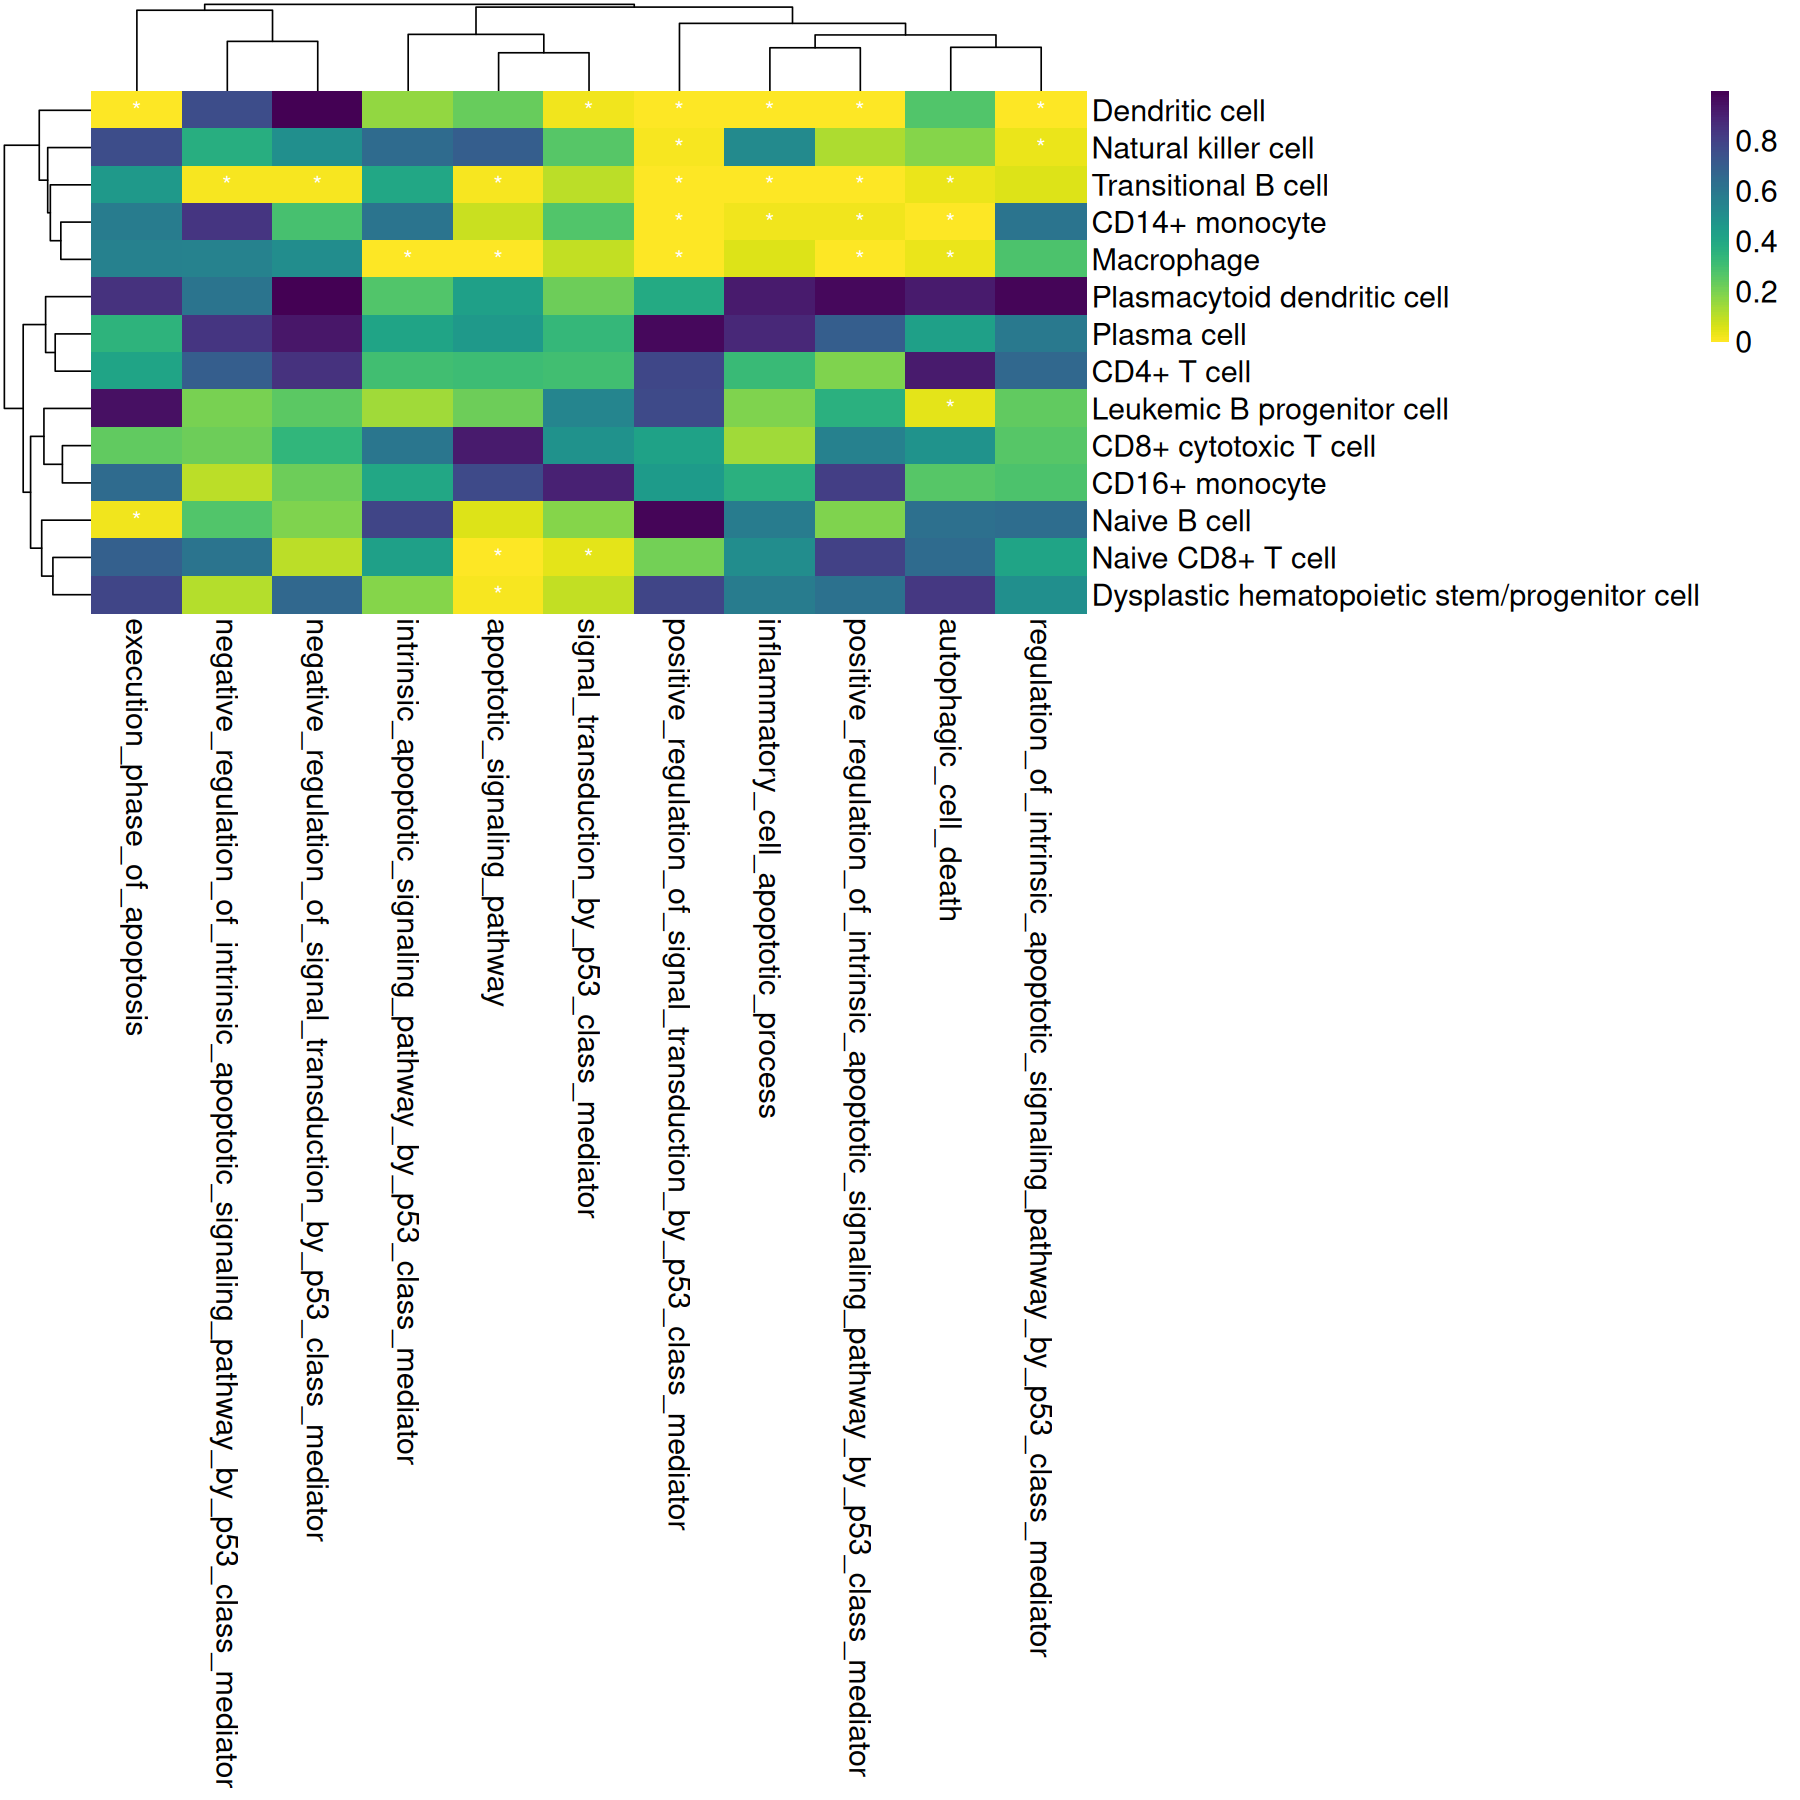

In [7]:
options(repr.plot.width=15, repr.plot.height=15)

for (i in 1:dim(genelist)[1]) {
    pathway <- gsub(genelist$pathway_name[i],pattern=" ",replacement="_")
    genes <- unique(str_split(genelist$genes[i],pattern = ",",simplify = T)[1,])
    PBMC <- AddModuleScore(PBMC,features = list(genes),name = pathway,seed = 123)
}

Idents(PBMC) <- PBMC$anno

data <- FetchData(PBMC,vars = c(paste0(gsub(genelist$pathway_name,pattern=" ",replacement="_"),"1"),"anno","ANXV"))
colnames(data) <- gsub(colnames(data),pattern = "1",replacement = "")
gam_list <- data.frame(matrix(nrow = 0,ncol = 11))
for (celltype in unique(data$anno)) {
  pval_list <- c()
  for (pathways in colnames(data)[1:11]) {
    model <- gam(data[which(data$anno == celltype),"ANXV"]~s(data[which(data$anno == celltype),pathways]))
    pval <- summary(model)$s.table[,"p-value"]
    pval_list <- c(pval_list,pval)
  }
  gam_list <- rbind(gam_list,pval_list)
}
colnames(gam_list) <- colnames(data)[1:11]
rownames(gam_list) <- unique(data$anno)

p <- pheatmap::pheatmap(gam_list,
                        color = viridis::viridis(100, direction = -1),
                        display_numbers = matrix(ifelse(gam_list < 0.05, "*", ""), 
                                                 nrow = nrow(gam_list)),
                        number_color = "white",
                        fontsize = 18)


g = ggplotify::as.ggplot(p)
ggsave(g,filename="pathway_gam_pval.pdf",width = 15,height = 15,units = "in",dpi = 300)